In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))
from src import *

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))
from src import *

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_processed.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


In [4]:
#dropping Unwanted Column and Defining Target Variale
df = df.drop(['AvgMonthlySpend','ContractValue','Churn'], axis=1)
y = df['MonthlyCharges']
X = df.drop('MonthlyCharges', axis=1)


In [5]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ServiceCount
0,0,0,1,0,1,0,1,29.85,True,False,...,False,False,False,False,False,False,False,True,False,1
1,1,0,0,0,34,1,0,1889.50,False,False,...,False,False,False,False,True,False,False,False,True,3
2,1,0,0,0,2,1,1,108.15,False,False,...,False,False,False,False,False,False,False,False,True,3
3,1,0,0,0,45,0,0,1840.75,True,False,...,False,False,False,False,True,False,False,False,False,3
4,0,0,0,0,2,1,1,151.65,False,False,...,False,False,False,False,False,False,False,True,False,1


In [6]:
from sklearn.model_selection import train_test_split
#Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

MAE : 0.7858677938779708
MSE : 1.0710303227382247
RMSE: 1.0349059487403793
R²  : 0.9987925410318929
Adjusted R² : 0.998757235214112


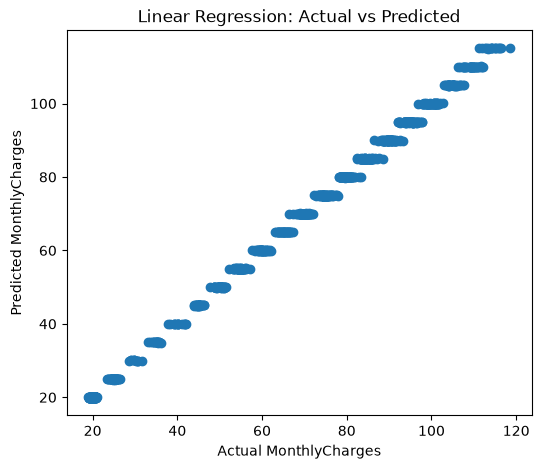

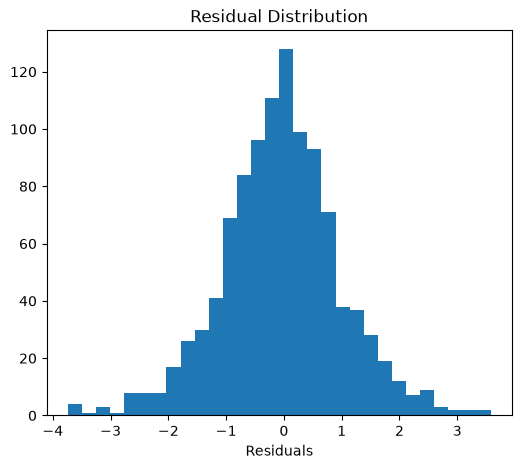

In [7]:
#Linear regression
from sklearn.linear_model import LinearRegression
import time
best_lr, training_time,y_pred=train_linear_regression(X_train, y_train,X_test)
mae,mse,rmse,r2,adj_r2=reg_metric(X_test,y_test,y_pred)
act_vs_pred(y_test,y_pred,"Linear Regression")
residual_distribution(y_test,y_pred)
results_reg = []

results_reg.append([
    "Linear Regression",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

In [8]:
corr = df.corr(numeric_only=True)

corr['MonthlyCharges'].sort_values(
    ascending=False
)

MonthlyCharges                           1.000000
InternetService_Fiber optic              0.787066
ServiceCount                             0.765874
TotalCharges                             0.650864
StreamingTV_Yes                          0.629603
StreamingMovies_Yes                      0.627429
MultipleLines_Yes                        0.490434
DeviceProtection_Yes                     0.482692
OnlineBackup_Yes                         0.441780
PaperlessBilling                         0.352150
TechSupport_Yes                          0.338304
OnlineSecurity_Yes                       0.296594
PaymentMethod_Electronic check           0.271625
tenure                                   0.247900
PhoneService                             0.247398
SeniorCitizen                            0.220173
Partner                                  0.096848
PaymentMethod_Credit card (automatic)    0.030550
Contract_One year                        0.004904
gender                                  -0.014569


MAE : 0.7858501081519229
MSE : 1.070991468789074
RMSE: 1.0348871768405838
R²  : 0.9987925848350871
Adjusted R² : 0.9987572802981014


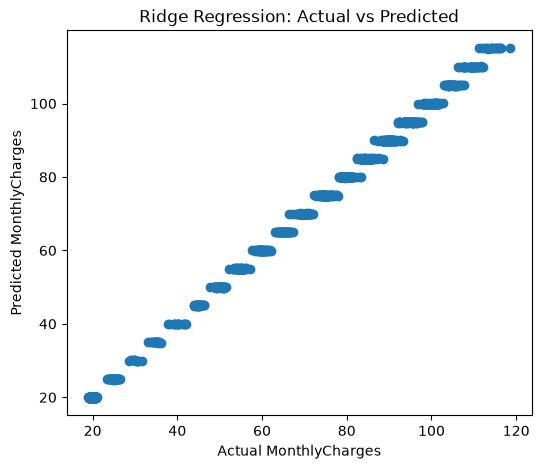

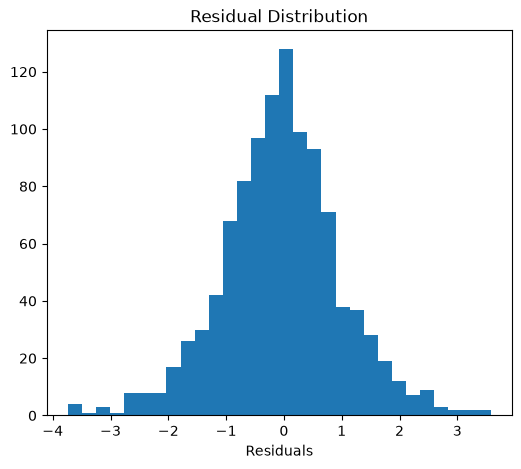

In [9]:
#Ridge regreesion
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
best_ridge, training_time,y_pred=train_ridge(X_train, y_train,X_test)
mae,mse,rmse,r2,adj_r2=reg_metric(X_test,y_test,y_pred)
act_vs_pred(y_test,y_pred,"Ridge Regression")
residual_distribution(y_test,y_pred)

results_reg.append([
    "Ridge",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

In [10]:
#Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import time
best_lasso,scaler,X_train_scaled, X_test_scaled,training_time, y_pred=train_lasso(X_train, y_train,X_test)

In [11]:
import pickle

with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("scaler.pk1 is saved")

scaler.pk1 is saved


In [12]:
import pickle

with open("../models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print(type(scaler))
print(scaler)

<class 'sklearn.preprocessing._data.StandardScaler'>
StandardScaler()


In [13]:
X_test_scaled = scaler.transform(X_test)

print(X_test_scaled.shape)

(1057, 30)


MAE : 0.7856919634386182
MSE : 1.070838614583586
RMSE: 1.0348133235437134
R²  : 0.998792757159976
Adjusted R² : 0.9987574576617296


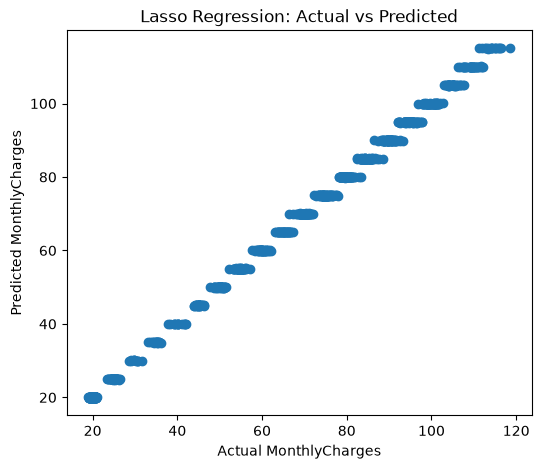

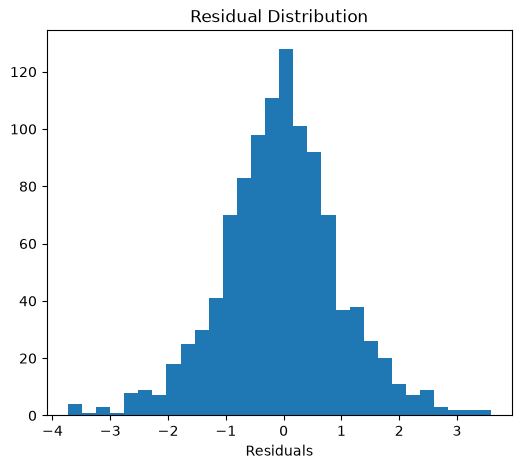

In [14]:
#Calculating metrics
mae,mse,rmse,r2,adj_r2=reg_metric(X_test,y_test,y_pred)
act_vs_pred(y_test,y_pred,"Lasso Regression")
residual_distribution(y_test,y_pred)

results_reg.append([
    "Lasso",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])



MAE : 0.7856765737432413
MSE : 1.0709017083645747
RMSE: 1.0348438086806022
R²  : 0.9987926860292617
Adjusted R² : 0.99875738445117


C:\Users\BALAJI REDDY U\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.922319e+03, tolerance: 4.478e+02
  model = cd_fast.enet_coordinate_descent(


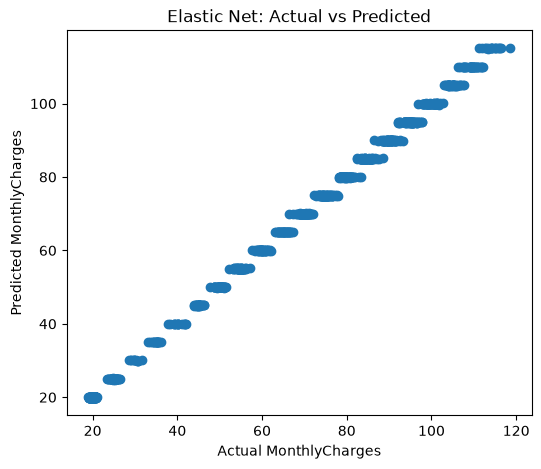

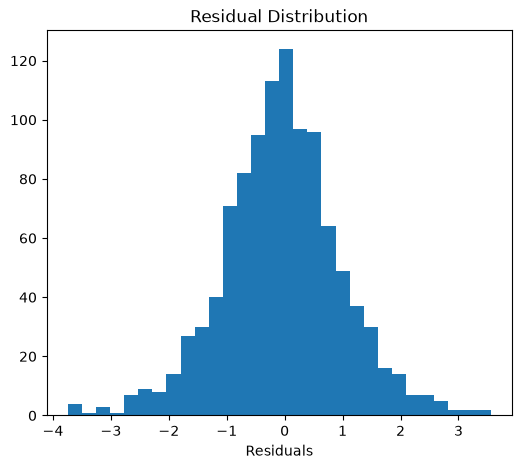

In [15]:
#Elastic net Regression
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
import time
model, training_time, y_pred=train_elasticnet(X_train, y_train,X_test)
mae,mse,rmse,r2,adj_r2=reg_metric(X_test,y_test,y_pred)
act_vs_pred(y_test,y_pred,"Elastic Net")
residual_distribution(y_test,y_pred)

results_reg.append([
    "Elastic Net",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])


MAE : 0.8379722551221432
MSE : 1.2866759363437128
RMSE: 1.134317387834513
R²  : 0.9985494263183754
Adjusted R² : 0.9985070118832402


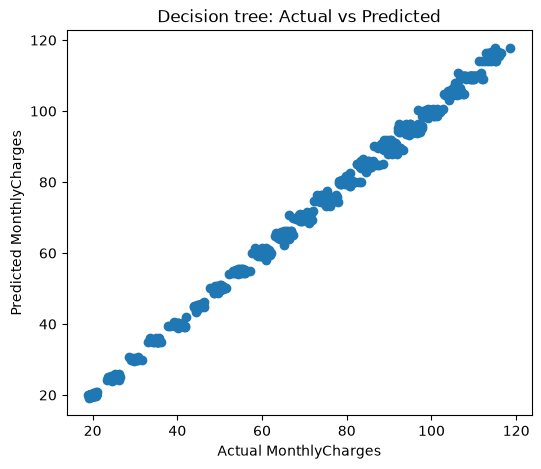

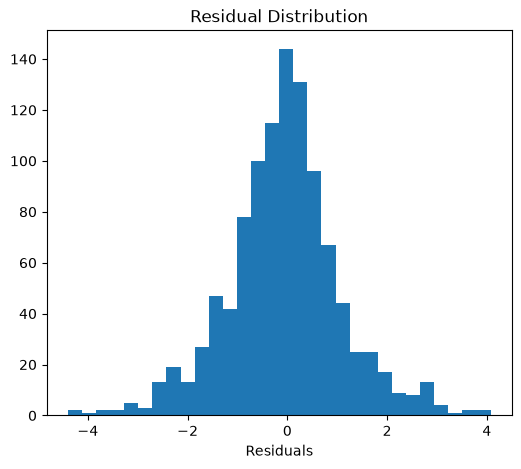

In [16]:
#Decision tree regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import time
model, training_time,y_pred=train_decision_tree_regressor(X_train, y_train,X_test)
mae,mse,rmse,r2,adj_r2=reg_metric(X_test,y_test,y_pred)
act_vs_pred(y_test,y_pred,"Decision tree")
residual_distribution(y_test,y_pred)

results_reg.append([
    "Decision tree",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])



MAE : 0.7843747569543177
MSE : 1.1495226722078689
RMSE: 1.0721579511470634
R²  : 0.9987040502681088
Adjusted R² : 0.9986661570010945


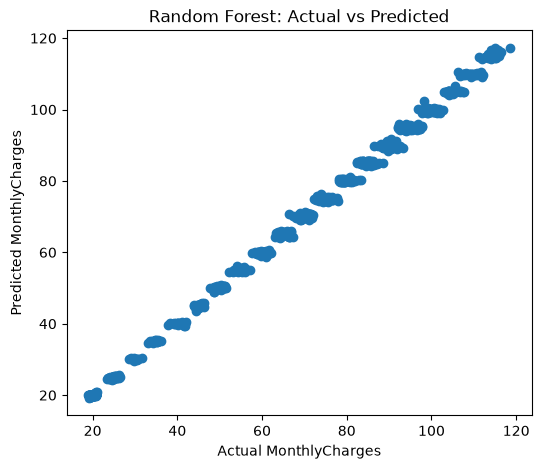

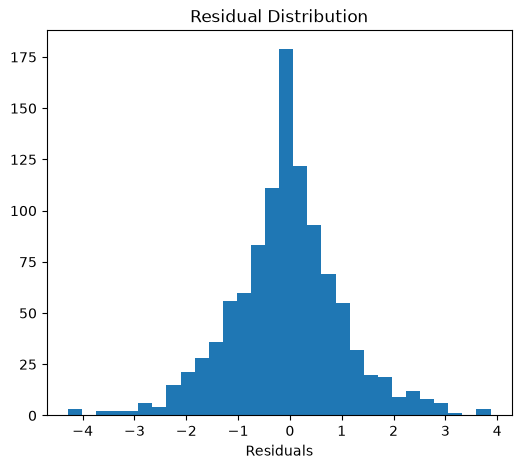

In [17]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import time
best_rf, training_time,y_pred=train_random_forest_regressor(X_train, y_train,X_test)
mae,mse,rmse,r2,adj_r2=reg_metric(X_test,y_test,y_pred)
act_vs_pred(y_test,y_pred,"Random Forest")
residual_distribution(y_test,y_pred)

results_reg.append([
    "Random Forest",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])



In [18]:
import pandas as pd

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

top10 = importance.sort_values(
    ascending=False
).head(10)

print(top10)

InternetService_Fiber optic            0.612067
ServiceCount                           0.337430
PhoneService                           0.010353
MultipleLines_No phone service         0.007702
StreamingMovies_No internet service    0.005398
MultipleLines_Yes                      0.005356
TechSupport_No internet service        0.005095
StreamingTV_Yes                        0.003442
StreamingMovies_Yes                    0.003083
StreamingTV_No internet service        0.002694
dtype: float64


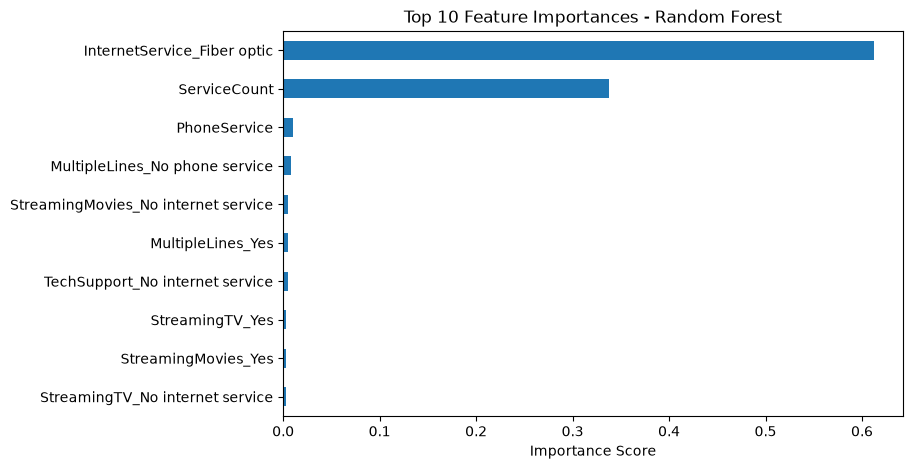

In [19]:
top10.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")

plt.show()

In [20]:
#random forest regressor complete


In [21]:

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import time

MAE : 0.8506325645030957
MSE : 1.2200019774548096
RMSE: 1.1045369968700955
R²  : 0.9986245932561273
Adjusted R² : 0.998584376684669


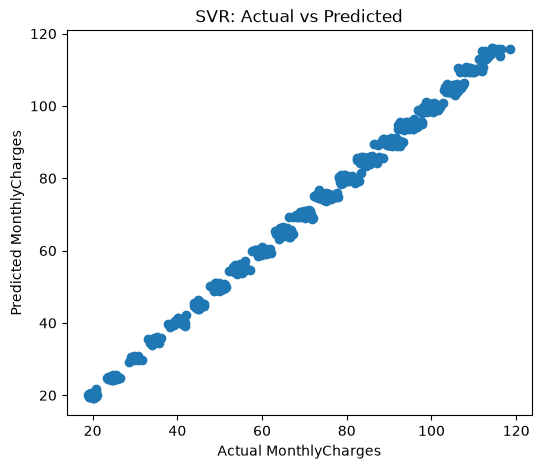

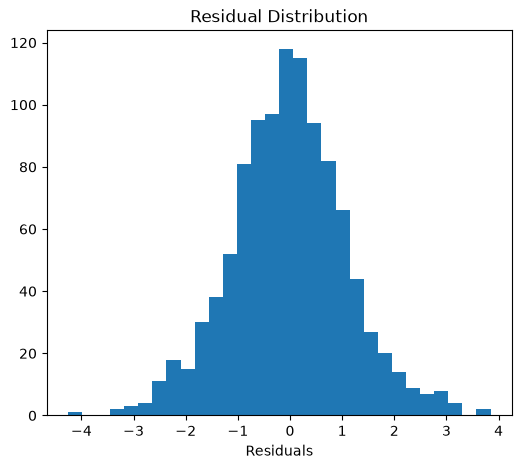

In [22]:
#SVR Regressor
best_svr,scaler,training_time,y_pred=train_svr(X_train, X_test, y_train)
mae,mse,rmse,r2,adj_r2=reg_metric(X_test,y_test,y_pred)
act_vs_pred(y_test,y_pred,"SVR")
residual_distribution(y_test,y_pred)

results_reg.append([
    "SVR",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])



In [23]:
results_reg_df = pd.DataFrame(
    results_reg,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adj. R²",
        "Training Time"
    ]
)

results_reg_df

,Model,MAE,MSE,RMSE,R²,Adj. R²,Training Time
0,Linear Regression,0.785868,1.071030,1.034906,0.998793,0.998757,0.067227
1,Ridge,0.785850,1.070991,1.034887,0.998793,0.998757,5.032951
2,Lasso,0.785692,1.070839,1.034813,0.998793,0.998757,0.124784
3,Elastic Net,0.785677,1.070902,1.034844,0.998793,0.998757,2.383212
4,Decision tree,0.837972,1.286676,1.134317,0.998549,0.998507,1.176767
5,Random Forest,0.784375,1.149523,1.072158,0.998704,0.998666,18.165512
6,SVR,0.850633,1.220002,1.104537,0.998625,0.998584,20.862295


In [24]:
import pickle

with open("../models/best_regressor.pkl", "wb") as f:
    pickle.dump(best_lasso, f)

print("Regressor saved!")

Regressor saved!


In [25]:
import pickle

with open("../models/best_regressor.pkl", "rb") as f:
    regressor = pickle.load(f)

print(type(regressor))
print(regressor)

<class 'sklearn.linear_model._coordinate_descent.Lasso'>
Lasso(alpha=0.001, max_iter=5000)


In [26]:
preds = regressor.predict(X_test.head())

print(preds)

[ 568.30966434  140.0316529   247.71544748 1295.75039084  480.87642397]


C:\Users\BALAJI REDDY U\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


In [27]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_
})

coef_df

,Feature,Coefficient
0,gender,0.008805
1,SeniorCitizen,0.008209
2,Partner,0.002405
3,Dependents,-0.028011
4,tenure,-0.004120
5,PhoneService,6.676896
6,PaperlessBilling,-0.006598
7,TotalCharges,0.000068
8,MultipleLines_No phone service,-6.676896
9,MultipleLines_Yes,4.993399


In [28]:
ridge_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_ridge.coef_
})

ridge_coef

,Feature,Coefficient
0,gender,0.008777
1,SeniorCitizen,0.008629
2,Partner,0.002492
3,Dependents,-0.028183
4,tenure,-0.004189
5,PhoneService,6.676576
6,PaperlessBilling,-0.006121
7,TotalCharges,0.000069
8,MultipleLines_No phone service,-6.676576
9,MultipleLines_Yes,4.993383


In [29]:
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lasso.coef_
})

lasso_coef

,Feature,Coefficient
0,gender,0.003256
1,SeniorCitizen,0.002293
2,Partner,0.000000
3,Dependents,-0.011762
4,tenure,-0.089979
5,PhoneService,5.813742
6,PaperlessBilling,-0.001510
7,TotalCharges,0.141450
8,MultipleLines_No phone service,-0.044542
9,MultipleLines_Yes,2.471115


In [30]:
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='AbsCoef',
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient,AbsCoef
10,InternetService_Fiber optic,24.900735,24.900735
5,PhoneService,6.676896,6.676896
8,MultipleLines_No phone service,-6.676896,6.676896
29,ServiceCount,6.648633,6.648633
9,MultipleLines_Yes,4.993399,4.993399
11,InternetService_No,-3.570678,3.570678
16,DeviceProtection_No internet service,-3.570678,3.570678
22,StreamingMovies_No internet service,-3.570678,3.570678
14,OnlineBackup_No internet service,-3.570678,3.570678
20,StreamingTV_No internet service,-3.570678,3.570678


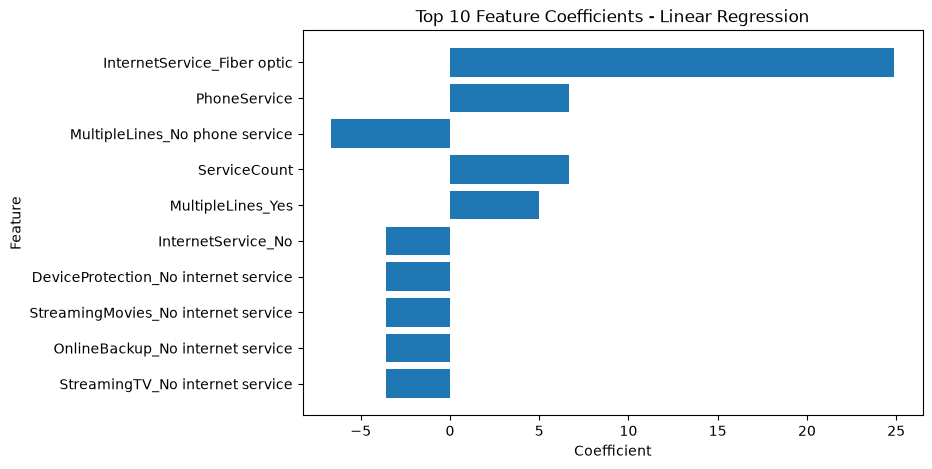

In [31]:
import matplotlib.pyplot as plt

top10 = coef_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Coefficient'])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Feature Coefficients - Linear Regression")
plt.gca().invert_yaxis()
plt.show()

In [32]:
comparison = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear': best_lr.coef_,
    'Ridge': best_ridge.coef_,
    'Lasso': best_lasso.coef_
})

comparison.head()

,Feature,Linear,Ridge,Lasso
0,gender,0.008805,0.008777,0.003256
1,SeniorCitizen,0.008209,0.008629,0.002293
2,Partner,0.002405,0.002492,0.000000
3,Dependents,-0.028011,-0.028183,-0.011762
4,tenure,-0.004120,-0.004189,-0.089979
